# Import statements

In [1]:
import numpy as np
import pandas as pd
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns
#import pickle

%matplotlib inline

In [2]:
# https://bioframe.readthedocs.io/en/latest/guide-intervalops.html
import bioframe as bf


In [3]:
import json


In [4]:
# # https://github.com/ipython/ipython/issues/10627
# import os
# os.environ['QT_QPA_PLATFORM']='offscreen'

# import ete3 as ETE

# from ete3 import Tree


#### Set matplotlib text export settings for Adobe Illustrator

In [5]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

#### Pandas Viewing Settings

In [6]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

### Import custom functions

In [7]:
#from gcutils.general import parse_PAFtools_VarTSV, label_DF_ByOvrLapGenes, label_PAF_DF_ByOvrLapGenes

from gcutils.gubbinsfuncs import get_RecombEvents_From_Gubbins_GFF_V2, label_Gubbins_Events_DF_ByOvrLap_H37RvGenes, label_Gubbins_Events_DF_ByOvrLap_HHRs

from gcutils.gubbinsfuncs import get_RecombEvents_From_Gubbins_GFF, parse_BaseReconstruction_EMBL_Gubbins



In [8]:
import numpy as np
import bioframe as bf

def annotate_HHR_with_GCE_overlaps(
    i_HHR_DF,
    i_GCE_DF,
    HHR_CoordCols=("Chr", "Start", "End"),
    GCE_CoordCols=("seqname", "start_0based", "end_1based"),
    GCE_ID_Col="EventID"
):
    """
    Annotate each row in i_HHR_DF with comma-separated GC EventIDs from i_GCE_DF that overlap.

    Parameters:
    - i_HHR_DF: DataFrame of high-homology regions.
    - i_GCE_DF: DataFrame of gene conversion events.
    - HHR_CoordCols: Tuple of (chrom, start, end) column names in i_HHR_DF.
    - GCE_CoordCols: Tuple of (chrom, start, end) column names in i_GCE_DF.
    - GCE_ID_Col: Column name in i_GCE_DF that contains unique GC Event IDs.

    Returns:
    - Annotated DataFrame with an "Overlap_GC_EventIDs" column.
    """

    listOf_Overlap_GCEs = []

    for _, row in i_HHR_DF.iterrows():
        i_Chrom = row[HHR_CoordCols[0]]
        i_Start = int(row[HHR_CoordCols[1]])
        i_End = int(row[HHR_CoordCols[2]])
        Target_Range = f"{i_Chrom}:{i_Start}-{i_End}"

        overlapping = bf.select(i_GCE_DF, Target_Range, cols=GCE_CoordCols)
        overlap_ids = ",".join(overlapping[GCE_ID_Col].astype(str)) if not overlapping.empty else "None"

        listOf_Overlap_GCEs.append(overlap_ids)

    annotated_df = i_HHR_DF.copy()
    annotated_df["Overlap_GC_EventIDs"] = listOf_Overlap_GCEs
    
    return annotated_df


# Import/parse processed H37rv genome annotations

In [9]:
RepoRef_Dir = "../../References"

AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir = f"{RepoRef_Dir}/201027_H37rv_AnnotatedGenes_And_IntergenicRegions"
H37Rv_GenomeAnnotations_Genes_TSV = f"{AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir}/H37Rv_GenomeAnnotations.Genes.tsv"

## H37Rv Gene Annotations TSV
H37Rv_GenomeAnno_Genes_DF = pd.read_csv(H37Rv_GenomeAnnotations_Genes_TSV, sep = "\t")
H37Rv_GeneInfo_Subset_DF = H37Rv_GenomeAnno_Genes_DF[["H37rv_GeneID", "Symbol", "Feature", "Functional_Category", "Is_Pseudogene", "Product", "PEandPPE_Subfamily", "ExcludedGroup_Category"]]

RvID_To_Symbol_Dict = dict(H37Rv_GeneInfo_Subset_DF[['H37rv_GeneID', 'Symbol']].values)

ESX_Genes_List_TSV = f"{RepoRef_Dir}/190927_H37rv_ListOf_ESXgenes.tsv"
Esx_Genes_DF = pd.read_csv(ESX_Genes_List_TSV, sep = '\t')

In [10]:
H37Rv_GenomeAnno_Genes_DF.head(1)

,Chrom,Start,End,Strand,H37rv_GeneID,Symbol,Feature,Functional_Category,Is_Pseudogene,Product,PEandPPE_Subfamily,ExcludedGroup_Category
0,NC_000962.3,0,1524,+,Rv0001,dnaA,CDS,information pathways,No,Chromosomal replication initiator protein DnaA,NaN,NotExcluded


# Parse in homology H37Rv mapping results (k19w19)

In [11]:
Main_Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V8"

H37_Rv_MM2_HomologyMapping_Dir = f"{Main_Project_Dir}/220502.H37Rv.HomologyMapping.k19w19.ProcessedData"       

# Define paths to output TSVs

### Homologous regions (MERGED)
H37Rv_HomologyRegions_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/H37rv.HomologousRegions.k19w19.tsv"

### Homology map (pairwise alignments)
H37Rv_HomologyMap_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/H37rv.HomologyMap.k19w19.tsv"
H37Rv_HomologyMap_NoOverlap_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/H37rv.HomologyMap.k19w19.NoOverlap.tsv"
H37Rv_HomologyMap_OnlyOverlap_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/H37rv.HomologyMap.k19w19.OnlyOverlap.tsv"

H37Rv_HomologyMap_NoOverlap_Processed_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/H37rv.HmMap.k19w19.NoOverlap.Processed.V2.tsv"

### Variants from the homology map alignments
H37Rv_HmMap_Var_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/H37rv.HomologyMap.k19w19.variants.tsv"
H37Rv_HmMap_Var_SNPs_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/H37rv.HomologyMap.k19w19.variants.snps.tsv"

### Parse in labeled homology-regions (w/ unique IDs)

HM_MergedRegions_Anno_DF = pd.read_csv(H37Rv_HomologyRegions_TSV, sep="\t")


### Parse in homology-map DFs (pairwise alignments between all homologous regions)

Mtb_HM_PAF_DF = pd.read_csv(H37Rv_HomologyMap_TSV, sep="\t")
Mtb_HM_PAF_DF_NoOverlapRegions = pd.read_csv(H37Rv_HomologyMap_NoOverlap_TSV, sep="\t")
Mtb_HM_PAF_DF_OnlyOverlapRegions = pd.read_csv(H37Rv_HomologyMap_OnlyOverlap_TSV, sep="\t")

HmPair_DF = pd.read_csv(H37Rv_HomologyMap_NoOverlap_Processed_TSV, sep="\t")

In [12]:
HM_MergedRegions_Anno_DF.head()[["HmRegionID", "Overlap_Genes", "Start", "End", "Length"]]

,HmRegionID,Overlap_Genes,Start,End,Length
0,HmRegion_000,Rv0071,80184,80523,339
1,HmRegion_001,"Rv0072,Rv0073",80623,82664,2041
2,HmRegion_002,"Rv0094c,Rv0095c",103705,105130,1425
3,HmRegion_003,PE_PGRS2,149571,149808,237
4,HmRegion_004,NaN,177203,177447,244


# Parse `TGEN-937-SR` sample metadata

In [13]:
Repo_MainDir = "../.."

Repo_DataDir = f"{Repo_MainDir}/Data"

Repo_RunInfoDir = f"{Repo_MainDir}/runInfo_TSVs"

TGen_1K_SampleInfo_CSV_PATH = f"{Repo_RunInfoDir}/TBportals.allTGEN_srrIds.forMax.csv"

TGen_1K_SM_V1_ResultsSummary_Dir = f"{Repo_DataDir}/Tgen1K_WGS_RunMetadata/211019_SM_TGen_1K_V1_ResultsSummary"

TGen_1K_SampleInfo_Filt_TSV_PATH = f"{Repo_DataDir}/Tgen1K_WGS_RunMetadata/211019_SM_TGen_1K_SampleInfo_V1.F2andCovFiltered.tsv"


TGen_1K_SRWGS_Stats_Filt_DF = pd.read_csv(TGen_1K_SampleInfo_Filt_TSV_PATH, sep = "\t")
TGen_1K_SRWGS_Stats_Filt_DF["PrimaryLineage"] = TGen_1K_SRWGS_Stats_Filt_DF["PrimaryLineage_Ill"]
TGen_1K_SRWGS_Stats_Filt_DF["SampleID"] = TGen_1K_SRWGS_Stats_Filt_DF["SampleName"]
TGen_1K_SRWGS_Stats_Filt_DF["Lineage"] = TGen_1K_SRWGS_Stats_Filt_DF["LineageCall_Illumina"]
TGen_1K_SRWGS_Stats_Filt_DF.shape

(937, 10)

### Define dictionaries that map sampleID to metadata labels

In [14]:
ID_To_PrimLineage_Dict = dict(TGen_1K_SRWGS_Stats_Filt_DF[['SampleID', 'PrimaryLineage']].values)
ID_To_SubLineage_Dict = dict( TGen_1K_SRWGS_Stats_Filt_DF[["SampleID", "Lineage"]].values)
ID_To_Dataset_Dict = dict(TGen_1K_SRWGS_Stats_Filt_DF[['SampleID', 'Dataset_Tag']].values)

# Parse `TGEN-937-SR` Gubbins Results

## Define directory paths to `TGEN-937-SR` Gubbins results

In [15]:
# Define varaint calling pipeline output directories

TGen1K_SRWGS_OutputDir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/250721.TGEN1K.GCAnalysis"


# Define path to TGEN01K Gubbins output (SR-WGS based predictions)
TGen1K_SRWGS_Gubbins_OutDir = f"{TGen1K_SRWGS_OutputDir}/Gubbins_Analysis_V1"

Gubbins_V1_OutputDir = TGen1K_SRWGS_Gubbins_OutDir


TGENSR_Gubbins_OutPrefix = "Tgen_937CI.Gubbins.FromSNVs.V1"

TGENSR_Gubbins_FullPrefix_PATH  = f"{TGen1K_SRWGS_Gubbins_OutDir}/{TGENSR_Gubbins_OutPrefix}"

TGENSR_Gubbins_FilePath_Dict = {}

TGENSR_Gubbins_FilePath_Dict["NodeLabelledTree_PATH"]        = f"{TGENSR_Gubbins_FullPrefix_PATH}.node_labelled.final_tree.tre"
TGENSR_Gubbins_FilePath_Dict["NodeToPriLineage_Dict_JSON"]   = f"{TGENSR_Gubbins_FullPrefix_PATH}.NodeToPrimaryLineage.json"
TGENSR_Gubbins_FilePath_Dict["BranchStats_CSV"]              = f"{TGENSR_Gubbins_FullPrefix_PATH}.per_branch_statistics.csv"
TGENSR_Gubbins_FilePath_Dict["BranchStats_WithLineage_CSV"]  = f"{TGENSR_Gubbins_FullPrefix_PATH}.per_branch_statistics.WithLineagePerNode.tsv"
TGENSR_Gubbins_FilePath_Dict["EventsPer_1kb_H37Rv_TSV"]      = f"{TGENSR_Gubbins_FullPrefix_PATH}.H37Rv.EventsPer1kb.tsv"
TGENSR_Gubbins_FilePath_Dict["EventsPer_Gene_H37Rv_TSV"]     = f"{TGENSR_Gubbins_FullPrefix_PATH}.H37Rv.EventsPerGene.tsv"
TGENSR_Gubbins_FilePath_Dict["EventsPer_HHR_H37Rv_TSV"]      = f"{TGENSR_Gubbins_FullPrefix_PATH}.H37Rv.EventsPerMergedHomologousRegion.tsv"

TGENSR_Gubbins_FilePath_Dict["RecombPred_Anno_TSV"]          = f"{TGENSR_Gubbins_FullPrefix_PATH}.recombination_predictions.Anno.tsv"
TGENSR_Gubbins_FilePath_Dict["RecombPred_CompToWGA151Events_TSV"] = f"{TGENSR_Gubbins_FullPrefix_PATH}.recombination_predictions.AnnoByOvrlapWiPrimAnalysis.V1.tsv"

TGENSR_Gubbins_FilePath_Dict["BaseAncRec_All_TSV"]           = f"{TGENSR_Gubbins_FullPrefix_PATH}.branch_base_reconstruction.AnnoByEvent.All.tsv"  
TGENSR_Gubbins_FilePath_Dict["BaseAncRec_EventsOnly_TSV"]    = f"{TGENSR_Gubbins_FullPrefix_PATH}.branch_base_reconstruction.AnnoByEvent.EventSNPsOnly.tsv" 


### Parse `TGENSR` recomb events TSVs

In [16]:
# Parse annotated events TSV
TGENSR_GRE_DF = pd.read_csv(TGENSR_Gubbins_FilePath_Dict["RecombPred_Anno_TSV"], sep = "\t")
TGENSR_GRE_DF.shape

(27, 28)

In [17]:
TGENSR_GRE_AnnoByWGA151Ovrlap_DF = pd.read_csv(TGENSR_Gubbins_FilePath_Dict["RecombPred_CompToWGA151Events_TSV"], sep = "\t")
TGENSR_GRE_AnnoByWGA151Ovrlap_DF.shape

(27, 35)

In [18]:
TGENSR_GRE_DF.head(2)

,seqname,source,feature,start_1based,end_1based,score,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,CenterOfRegion,EventLen,Lineage,Overlap_Genes,Overlap_Gene_RvIDs,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,EventID,HmAln_Count,HmAln_Ovrlap,HHR_Count,HHR_Ovrlap,Overlap_HHRs
0,NC_000962.3,GUBBINS,CDS,333120,333212,0.0,.,internal_985,internal_986,158.013591,8,"['SRR10379945', 'SRR7516364', 'SRR10380193', '...",333119,333165.5,93,lineage4,"vapC25,vapB25","Rv0277c,Rv0277A",False,False,False,True,Event_001,1,1,1,1,HmRegion_009
1,NC_000962.3,GUBBINS,CDS,473800,473971,0.0,.,internal_1262,SRR6807674,70.598206,6,['SRR6807674'],473799,473885.0,172,lineage4,Rv0393,Rv0393,False,False,True,False,Event_002,1,1,1,1,HmRegion_018


### Parse Gubbins recombination events counted over "1 kb windows", "Gene-level", "Merged Homologous Regions"

In [19]:
GCE_Per1kb_Stats_DF = pd.read_csv(TGENSR_Gubbins_FilePath_Dict["EventsPer_1kb_H37Rv_TSV"], sep = "\t")
GCE_Per1kb_Stats_DF["CenterOfRegion"] = ((GCE_Per1kb_Stats_DF["Start"] + GCE_Per1kb_Stats_DF["End"]) / 2)
GCE_Per1kb_Stats_DF.shape

(4412, 7)

In [20]:
GCE_PerGene_Stats_DF = pd.read_csv(TGENSR_Gubbins_FilePath_Dict["EventsPer_Gene_H37Rv_TSV"], sep = "\t")
GCE_PerGene_Stats_DF["CenterOfRegion"] = ((GCE_PerGene_Stats_DF["Start"] + GCE_PerGene_Stats_DF["End"]) / 2)
GCE_PerGene_Stats_DF.shape

(4079, 14)

In [21]:
GCE_PerGene_Stats_Atleast1_DF = GCE_PerGene_Stats_DF.query("pGCE_Count > 0")
GCE_PerGene_Stats_Atleast1_DF.shape

(25, 14)

In [22]:
TGEN_GCE_PerHHR_Stats_DF = pd.read_csv(TGENSR_Gubbins_FilePath_Dict["EventsPer_HHR_H37Rv_TSV"], sep = "\t")

PerHHR_SelectCol = ["HmRegionID", "Overlap_Genes", "Chr", "Start", "End", "Center", "Length", "pGCE_Count" ] 

TGEN_GCE_PerHHR_Stats_V2_DF = TGEN_GCE_PerHHR_Stats_DF[PerHHR_SelectCol]

TGEN_GCE_PerHHR_Stats_V2_DF.shape

(197, 8)

In [23]:
TGEN_GCE_PerHHR_Stats_V2_DF.head()

,HmRegionID,Overlap_Genes,Chr,Start,End,Center,Length,pGCE_Count
0,HmRegion_000,Rv0071,NC_000962.3,80184,80523,80353.5,339,0
1,HmRegion_001,"Rv0072,Rv0073",NC_000962.3,80623,82664,81643.5,2041,0
2,HmRegion_002,"Rv0094c,Rv0095c",NC_000962.3,103705,105130,104417.5,1425,0
3,HmRegion_003,PE_PGRS2,NC_000962.3,149571,149808,149689.5,237,0
4,HmRegion_004,NaN,NC_000962.3,177203,177447,177325.0,244,0


In [24]:
TGEN_GCE_PerHHR_Stats_V2_DF.shape

(197, 8)

### Create DF of HHRs w/ more than 1 GC Event detected in `TGENSR` dataset

In [25]:

TGEN_GCE_PerHHR_WiOvrLapGCE_Stats_DF = annotate_HHR_with_GCE_overlaps(TGEN_GCE_PerHHR_Stats_V2_DF.query("pGCE_Count > 0"),
                                                                      TGENSR_GRE_DF)

TGEN_GCE_PerHHR_WiOvrLapGCE_Stats_DF.shape

(17, 9)

### Look at single `TGENSR` event that DOES NOT overlap w/ any HHR

In [26]:
TGENSR_GRE_AnnoByWGA151Ovrlap_DF.query("HHR_Count == 0 ")

,seqname,source,feature,start_1based,end_1based,score,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,CenterOfRegion,EventLen,Lineage,Overlap_Genes,Overlap_Gene_RvIDs,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,EventID,HmAln_Count,HmAln_Ovrlap,HHR_Count,HHR_Ovrlap,Overlap_HHRs,LenOfTaxaList,Ovrlap_HRR_Wi_pGCE_InWGA151,Ovrlap_HRR_Wi_mGCE_InWGA151,Ovrlap_Any_pGCE_InWGA151,Reseq_With_PacBioHifi,Reseq_VerficationIsolate,Reseq_ControlIsolate
20,NC_000962.3,GUBBINS,CDS,3477266,3477370,0.0,.,internal_1082,SRR10397163,175.415705,5,['SRR10397163'],3477265,3477317.5,105,lineage4,Rv3108,Rv3108,False,False,False,True,Event_021,0,0,0,0,NaN,1,0,0,0,True,TB3572,TB6976


In [27]:
TGENSR_GRE_AnnoByWGA151Ovrlap_DF.query("HHR_Count == 0 ")[["EventID", "Overlap_Genes", "start_0based", "end_1based", "taxa_List", "snp_count"]]

,EventID,Overlap_Genes,start_0based,end_1based,taxa_List,snp_count
20,Event_021,Rv3108,3477265,3477370,['SRR10397163'],5


In [28]:
GCE21_Rv3108_NoHHR_Center = int((3477265 + 3477370)/ 2)
GCE21_Rv3108_NoHHR_Center

3477317

# Analysis Section

## Part 1 - Look at info of 27 putative events identified using the short-read WGS of `TGEN-937` dataset

### A) Look at table of ALL detected events in `TGENSR` dataset

In [29]:
GCE_TargetColn_Set2 = ["EventID", "Overlap_Genes", "snp_count", "LenOfTaxaList",
                   "Child_Node",
                   "Lineage",   
                   "Overlap_HHRs", #"HHR_Ovrlap",
                   "Ovrlap_HRR_Wi_pGCE_InWGA151",
                   "Reseq_With_PacBioHifi",
                   "Reseq_VerficationIsolate", "Reseq_ControlIsolate"] 


In [30]:
TGENSR_GRE_AnnoByWGA151Ovrlap_DF[GCE_TargetColn_Set2]

,EventID,Overlap_Genes,snp_count,LenOfTaxaList,Child_Node,Lineage,Overlap_HHRs,Ovrlap_HRR_Wi_pGCE_InWGA151,Reseq_With_PacBioHifi,Reseq_VerficationIsolate,Reseq_ControlIsolate
0,Event_001,"vapC25,vapB25",8,34,internal_986,lineage4,HmRegion_009,1,True,TB6733,TB3898
1,Event_002,Rv0393,6,1,SRR6807674,lineage4,HmRegion_018,1,False,NaN,NaN
2,Event_003,"vapB31,vapC31",14,2,internal_1062,lineage4,HmRegion_031,1,True,TB6599,TB6977
3,Event_004,Rv0750,9,1,SRR6807728,lineage4,HmRegion_032,1,False,NaN,NaN
4,Event_005,Rv0750,7,145,internal_1181,lineage4,HmRegion_032,1,False,NaN,NaN
5,Event_006,"Rv0979c,rpmF,PE_PGRS18",7,1,SRR10397175,lineage2,"HmRegion_039,HmRegion_040",2,True,TB3305,TB3706
6,Event_007,Rv1148c,5,21,internal_946,lineage4,HmRegion_049,1,True,TB6755,TB7044
7,Event_008,PPE18,5,159,internal_1167,lineage4,HmRegion_052,1,False,NaN,NaN
8,Event_009,PPE18,8,1,SRR6807728,lineage4,HmRegion_052,1,False,NaN,NaN
9,Event_010,"PPE18,esxK,esxL",5,1,SRR10380108,lineage4,"HmRegion_052,HmRegion_053",2,True,TB6552,TB6765


### B) Look at table of HHRs overlapping w/ detected events in `TGENSR` dataset

In [31]:
TGEN_GCE_PerHHR_WiOvrLapGCE_Stats_DF

,HmRegionID,Overlap_Genes,Chr,Start,End,Center,Length,pGCE_Count,Overlap_GC_EventIDs
9,HmRegion_009,"vapC25,vapB25,PE_PGRS3",NC_000962.3,332698,336379,334538.5,3681,1,Event_001
18,HmRegion_018,Rv0393,NC_000962.3,473743,474099,473921.0,356,1,Event_002
31,HmRegion_031,"PE_PGRS10,vapB31,vapC31",NC_000962.3,838485,841665,840075.0,3180,1,Event_003
32,HmRegion_032,Rv0750,NC_000962.3,842019,842331,842175.0,312,2,"Event_004,Event_005"
39,HmRegion_039,PE_PGRS17,NC_000962.3,1093195,1094592,1093893.5,1397,1,Event_006
40,HmRegion_040,"Rv0979c,rpmF,PE_PGRS18",NC_000962.3,1094827,1096692,1095759.5,1865,1,Event_006
49,HmRegion_049,Rv1148c,NC_000962.3,1276292,1277797,1277044.5,1505,1,Event_007
52,HmRegion_052,"PE13,PPE18",NC_000962.3,1338923,1340433,1339678.0,1510,5,"Event_008,Event_009,Event_010,Event_011,Event_012"
53,HmRegion_053,"PPE18,esxK,esxL",NC_000962.3,1340494,1341292,1340893.0,798,1,Event_010
59,HmRegion_059,PPE19,NC_000962.3,1532461,1533653,1533057.0,1192,2,"Event_013,Event_014"


In [32]:
TGEN_GCE_PerHHR_WiOvrLapGCE_Stats_DF[["HmRegionID", "Overlap_Genes", "Center", "Overlap_GC_EventIDs"]]

,HmRegionID,Overlap_Genes,Center,Overlap_GC_EventIDs
9,HmRegion_009,"vapC25,vapB25,PE_PGRS3",334538.5,Event_001
18,HmRegion_018,Rv0393,473921.0,Event_002
31,HmRegion_031,"PE_PGRS10,vapB31,vapC31",840075.0,Event_003
32,HmRegion_032,Rv0750,842175.0,"Event_004,Event_005"
39,HmRegion_039,PE_PGRS17,1093893.5,Event_006
40,HmRegion_040,"Rv0979c,rpmF,PE_PGRS18",1095759.5,Event_006
49,HmRegion_049,Rv1148c,1277044.5,Event_007
52,HmRegion_052,"PE13,PPE18",1339678.0,"Event_008,Event_009,Event_010,Event_011,Event_012"
53,HmRegion_053,"PPE18,esxK,esxL",1340893.0,Event_010
59,HmRegion_059,PPE19,1533057.0,"Event_013,Event_014"


## Look at table of events selected for resequencing w/ PacBio HiFi - 12 events

In [33]:
TGENSR_GRE_AnnoByWGA151Ovrlap_DF[GCE_TargetColn_Set2].query("Reseq_With_PacBioHifi == True")

,EventID,Overlap_Genes,snp_count,LenOfTaxaList,Child_Node,Lineage,Overlap_HHRs,Ovrlap_HRR_Wi_pGCE_InWGA151,Reseq_With_PacBioHifi,Reseq_VerficationIsolate,Reseq_ControlIsolate
0,Event_001,"vapC25,vapB25",8,34,internal_986,lineage4,HmRegion_009,1,True,TB6733,TB3898
2,Event_003,"vapB31,vapC31",14,2,internal_1062,lineage4,HmRegion_031,1,True,TB6599,TB6977
5,Event_006,"Rv0979c,rpmF,PE_PGRS18",7,1,SRR10397175,lineage2,"HmRegion_039,HmRegion_040",2,True,TB3305,TB3706
6,Event_007,Rv1148c,5,21,internal_946,lineage4,HmRegion_049,1,True,TB6755,TB7044
9,Event_010,"PPE18,esxK,esxL",5,1,SRR10380108,lineage4,"HmRegion_052,HmRegion_053",2,True,TB6552,TB6765
10,Event_011,PPE18,7,3,internal_1140,lineage4,HmRegion_052,1,True,TB6778,TB6973
12,Event_013,PPE19,6,4,internal_1039,lineage4,HmRegion_059,1,True,TB6786,TB3256
18,Event_019,PPE46,8,6,internal_1061,lineage4,HmRegion_152,1,True,TB6977,TB6976
20,Event_021,Rv3108,5,1,SRR10397163,lineage4,NaN,0,True,TB3572,TB6976
21,Event_022,PPE56,7,4,internal_1023,lineage4,HmRegion_170,1,True,TB6596,TB8073


In [34]:
TGENSR_GRE_AnnoByWGA151Ovrlap_DF[GCE_TargetColn_Set2].query("Reseq_With_PacBioHifi == True").shape

(12, 11)

# Output Results table for `TGENSR` analysis (27 events detected w/ SR-WGS)

In [35]:
!mkdir ./TGENSR_937CI_GCE_Results/

mkdir: cannot create directory ‘./TGENSR_937CI_GCE_Results/’: File exists


In [36]:
TGEN_GCE_PerHHR_WiOvrLapGCE_Stats_DF.shape

(17, 9)

In [37]:
TGEN_GCE_PerHHR_WiOvrLapGCE_Stats_DF.to_csv("./TGENSR_937CI_GCE_Results/TGEN_GCE_PerHHR_WiOvrLapGCE_Stats_DF.tsv",
                                            sep ="\t", index=False)


# Viz Genomic Distribution of `TGENSR` Events

In [38]:
from pycirclize import Circos

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch


In [39]:
TGEN_GCE_PerHHR_WiOvrLapGCE_Stats_DF.head(2)

,HmRegionID,Overlap_Genes,Chr,Start,End,Center,Length,pGCE_Count,Overlap_GC_EventIDs
9,HmRegion_009,"vapC25,vapB25,PE_PGRS3",NC_000962.3,332698,336379,334538.5,3681,1,Event_001
18,HmRegion_018,Rv0393,NC_000962.3,473743,474099,473921.0,356,1,Event_002


In [40]:
# Extracting the data for plotting

HHR_pGCE_Pos = TGEN_GCE_PerHHR_WiOvrLapGCE_Stats_DF['Center']

HHR_pGCE_Freq = TGEN_GCE_PerHHR_WiOvrLapGCE_Stats_DF['pGCE_Count']


In [41]:
np.max(np.array( HHR_pGCE_Freq))

5

## Try 1 - `circular` Genome Viz of `TGENSR` detected events

In [42]:
!mkdir ./TGENSR_937CI_GCE_Results/

mkdir: cannot create directory ‘./TGENSR_937CI_GCE_Results/’: File exists


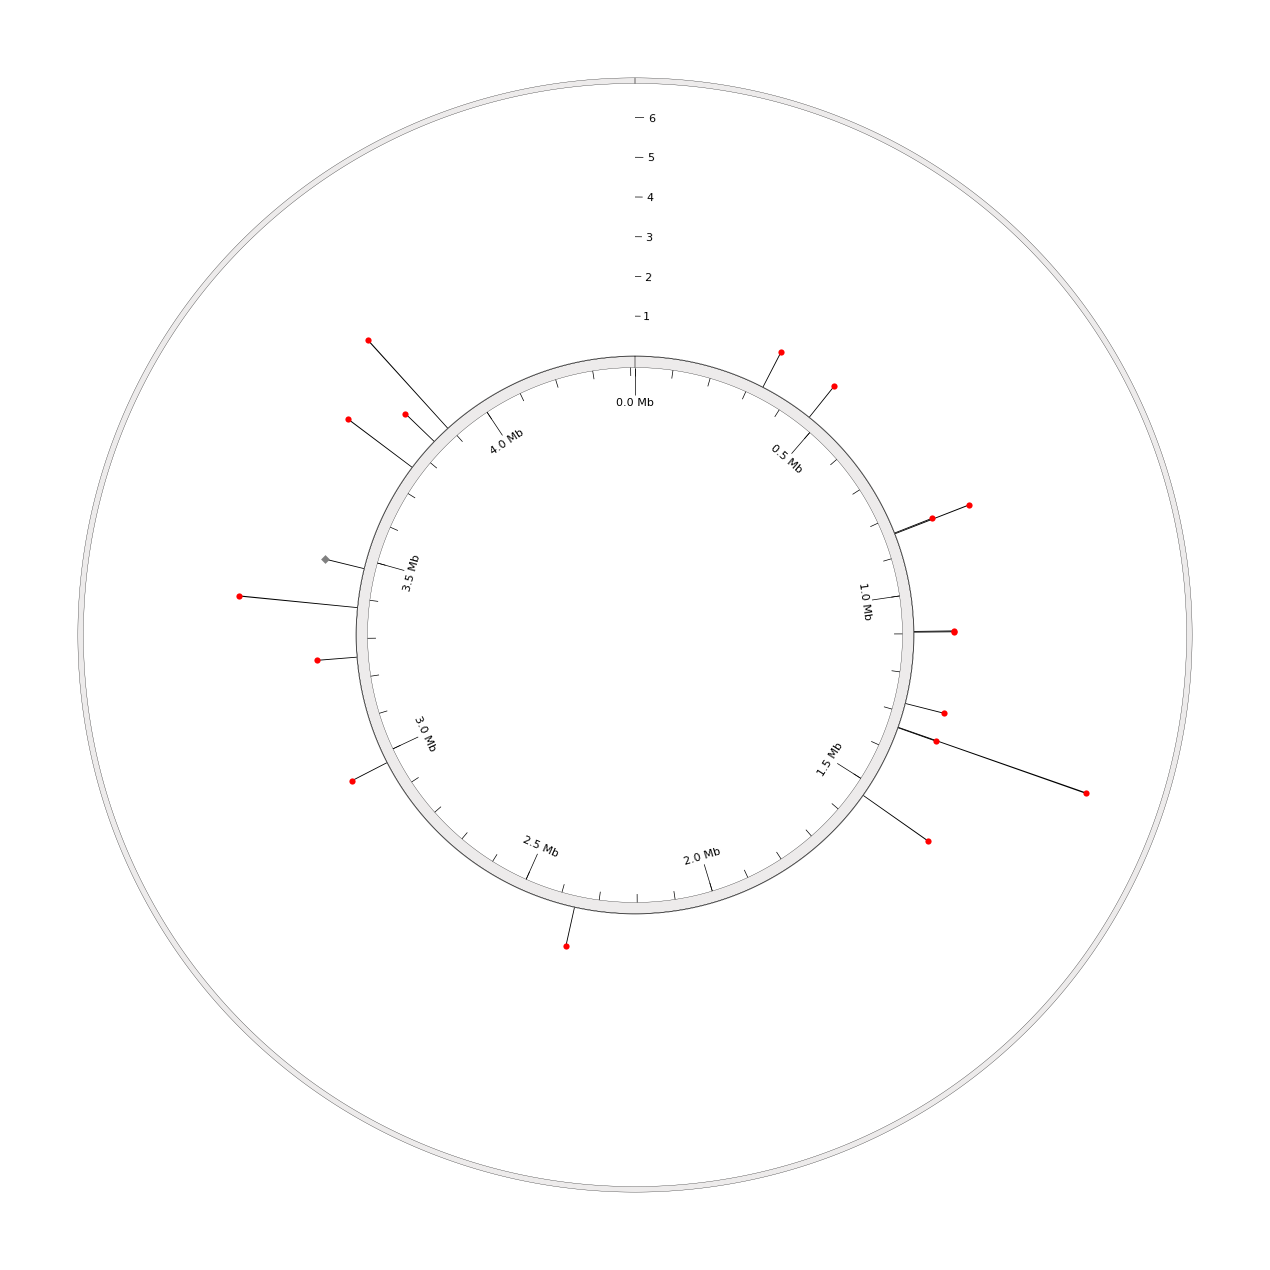

In [43]:
# main fig params
color_dict = {'nucdiv': '#4E4F51',
              'events': '#39618C',
              'GC_arcs': '#F6605E',
              'hm_arcs' : 'blue', #'grey',
              'scale_track': '#edebeb'}

circos = Circos(sectors={"NC_000962.3": 4411532}, endspace=False)
sector = circos.get_sector("NC_000962.3")


outerring_track = sector.add_track((99, 100))
outerring_track.axis(fc=color_dict['scale_track'], 
                 lw=0.2)

## SCALE TRACK
major_ticks_interval, minor_ticks_interval = 500000, 100000
scale_track = sector.add_track((48, 50))

# background color and line
scale_track.axis(fc=color_dict['scale_track'], 
                 lw=0.2)

# ticks
scale_track.xticks_by_interval(major_ticks_interval, 
                               label_size=8, 
                               tick_length=5, 
                               outer=False,
                               show_bottom_line=False,
                               label_orientation='horizontal',
                               line_kws=dict(ec='black'),
                               label_formatter=lambda v: f"{v/ 10 ** 6:.1f} Mb")

scale_track.xticks_by_interval(minor_ticks_interval, 
                               tick_length=1.5, 
                               outer=False,
                               show_label=False)



## EVENTS TRACK
events_axis_track = sector.add_track((50, 50.1))
events_axis_track.axis(lw=0.2)

events_track = sector.add_track((50.1, 100), 
                                r_pad_ratio=0)
events_track.axis(lw=0)

events_track.bar(np.array(HHR_pGCE_Pos),
                     np.array( HHR_pGCE_Freq),
                     vmax = 7, #vmax = np.max(np.array( HHR_pGCE_Freq)) + 4,
                     color= "black", width = 2000)

events_track.scatter(np.array(HHR_pGCE_Pos),
                     np.array( HHR_pGCE_Freq),
                     vmax = 7, #vmax = np.max(np.array( HHR_pGCE_Freq)) + 4,
                     
                     color= "red",
                     s = 20,
                     marker='o',)


# Manually add a mark for the event that occured in a non-HHR region
events_track.bar(np.array([GCE21_Rv3108_NoHHR_Center]),
                 np.array([1]),
                 vmax = 7, #vmax = np.max(np.array( HHR_pGCE_Freq)) + 4,
                 color= "black", width = 2000)

events_track.scatter(np.array([GCE21_Rv3108_NoHHR_Center]),
                 np.array([1]),
                     vmax = 7, #vmax = np.max(np.array( HHR_pGCE_Freq)) + 4,
                     color= "grey",
                     s = 20,
                     marker='D',) # https://matplotlib.org/stable/api/markers_api.html


y = [1, 2, 3, 4, 5, 6]
y_labels = list(map(str, y))
events_track.yticks(y,
                    y_labels,
                    vmax = 7)


##########################################
fig = circos.plotfig(figsize = (12, 12))
fig.savefig('./TGENSR_937CI_GCE_Results/TGENSR.27GCE.GenomicDistr.Circular.V1.svg')
fig.savefig('./TGENSR_937CI_GCE_Results/TGENSR.27GCE.GenomicDistr.Circular.V1.png')

# Add legend
handles = [
    # Patch(color=color_dict['events'], label="All Putative Gene Conversion Events"),
    Patch(color=color_dict['events'], label="# of overlapping putative GC events"),
    #Patch(color= "blue", label="High-Homology Regions w/ no mapped events"),

]

#_ = circos.ax.legend(handles=handles, bbox_to_anchor=(1.3, 1), loc="right", fontsize=10)


## Try 2 - `linear` Genome Viz of `TGENSR` detected events

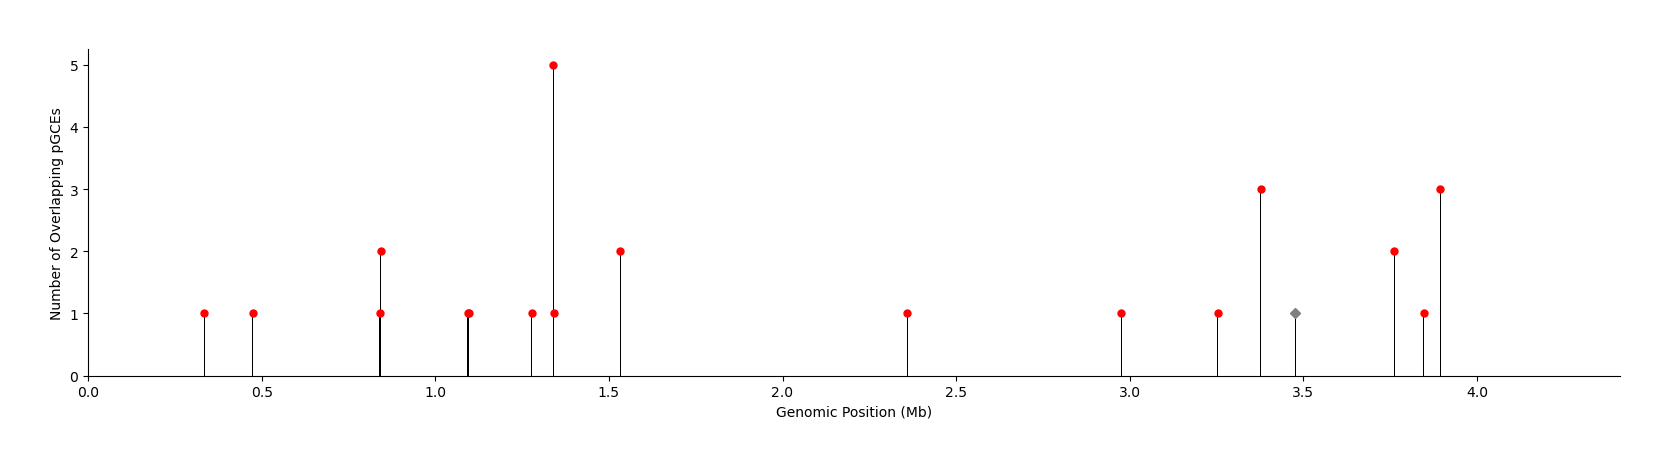

In [44]:
from matplotlib.ticker import FuncFormatter

# Function to convert base pairs to megabases
def bp_to_mb(x, pos):
    return f'{x * 1e-6:.1f}'

# Create the figure and axes
fig, ax = plt.subplots(figsize=(16, 4))

# Plot frequency of putative GC Events per HHRs
ax.bar(HHR_pGCE_Pos, HHR_pGCE_Freq, width=3000, color='black')
ax.plot(HHR_pGCE_Pos, HHR_pGCE_Freq, 'o', color='red', markersize=5)


# Plot location of Event_021, which is not in any HHR (in H37Rv)
ax.bar(GCE21_Rv3108_NoHHR_Center, 1, width=3000, color='black')
ax.plot(GCE21_Rv3108_NoHHR_Center, 1, 'D', color='grey', markersize=5)


# Format x-axis as megabases
ax.set_xlim(0, 4412000)
ax.xaxis.set_major_formatter(FuncFormatter(bp_to_mb))

# Aesthetics
ax.set_xlabel("Genomic Position (Mb)")
ax.set_ylabel("Number of Overlapping pGCEs")
#ax.set_title("Distribution of Putative Gene Conversion Events Across HHRs")
#ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
sns.despine()
fig.savefig('./TGENSR_937CI_GCE_Results/TGENSR.27GCE.GenomicDistr.Linear.V1.svg')
fig.savefig('./TGENSR_937CI_GCE_Results/TGENSR.27GCE.GenomicDistr.Linear.V1.png')
plt.show()




# Extras